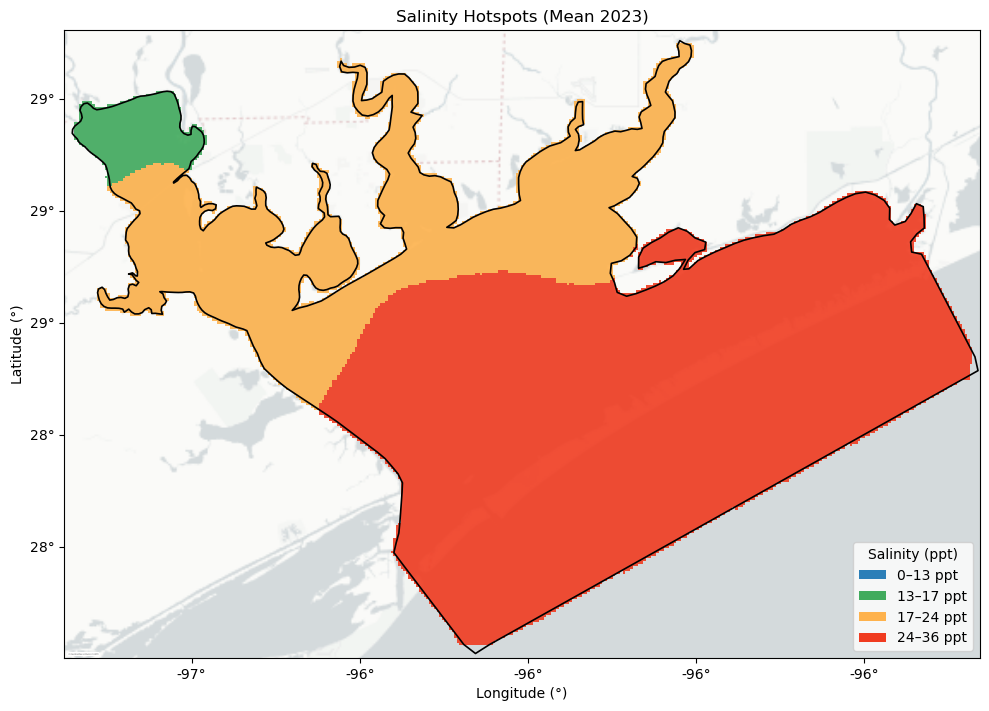

In [1]:
# --- Requirements ---
# pip install rasterio numpy matplotlib contextily geopandas pyproj

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MaxNLocator
import contextily as ctx
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
import geopandas as gpd
from pyproj import Transformer

# ---------------- USER INPUT ----------------
raster_path = r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\Mean_2023.tif"
save_png    = r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Simulation_results\2023\Mean_2023_hotspots.png"
boundary_zip = r"C:\Users\dpn_s\Documents\PhD_Research\Salinity_Model_Matagorda\Shape_Files\matagorda_mesh_outer_boundary.zip"
USE_BASEMAP = True
# --------------------------------------------

# Discrete bins & labels (ppt)
bins   = [0.0, 13.0, 17.0, 24.0, 36.0]
labels = ["0–13 ppt", "13–17 ppt", "17–24 ppt", "24–36 ppt"]

# Colors for each bin (low → high salinity)
colors = ["#2c7fb8", "#41ab5d", "#feb24c", "#f03b20"]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bins, cmap.N, clip=False)

# ---- Read source raster ----
with rasterio.open(raster_path) as src:
    src_arr = src.read(1).astype("float32")
    src_nodata = src.nodata
    src_crs = src.crs
    src_transform = src.transform
    src_bounds = src.bounds
    src_height, src_width = src.height, src.width

# NoData -> NaN for proper binning
if src_nodata is not None:
    src_arr = np.where(src_arr == src_nodata, np.nan, src_arr)

# ---- Reproject to EPSG:3857 for basemap alignment ----
dst_crs = CRS.from_epsg(3857) if USE_BASEMAP else src_crs
if USE_BASEMAP:
    transform_3857, width_3857, height_3857 = calculate_default_transform(
        src_crs, dst_crs, src_width, src_height, *src_bounds
    )
    dst_arr = np.full((height_3857, width_3857), np.nan, dtype="float32")

    reproject(
        source=src_arr,
        destination=dst_arr,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=transform_3857,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    plot_arr = dst_arr
    out_transform = transform_3857
    out_crs = dst_crs
else:
    plot_arr = src_arr
    out_transform = src_transform
    out_crs = src_crs

# ---- Extent from transform ----
def extent_from_transform(transform, width, height):
    x0, y0 = transform * (0, 0)
    x1, y1 = transform * (width, height)
    xmin, xmax = (x0, x1) if x0 < x1 else (x1, x0)
    ymin, ymax = (y1, y0) if y1 < y0 else (y0, y1)
    return [xmin, xmax, ymin, ymax]

extent = extent_from_transform(out_transform, plot_arr.shape[1], plot_arr.shape[0])

# ---- Classify to bins; keep only values within [min, max] ----
classified = np.full_like(plot_arr, np.nan, dtype="float32")
mask_in = np.isfinite(plot_arr) & (plot_arr >= bins[0]) & (plot_arr <= bins[-1])
classified[mask_in] = plot_arr[mask_in]

# ---- Read boundary shapefile (zip) and reproject to out_crs ----
gdf_bnd = gpd.read_file(boundary_zip)
if gdf_bnd.crs is None:
    # set this if your boundary lacks CRS (adjust if needed)
    gdf_bnd = gdf_bnd.set_crs("EPSG:32614")
gdf_bnd = gdf_bnd.to_crs(out_crs)

# ---- Plot (basemap first, then data, then boundary) ----
fig, ax = plt.subplots(figsize=(10, 8))

# Fix view box first so basemap and raster align perfectly
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

# Basemap (requires EPSG:3857)
if USE_BASEMAP:
    if out_crs.to_epsg() != 3857:
        raise RuntimeError("When USE_BASEMAP=True, data must be in EPSG:3857.")
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, attribution_size=0)

# Classified raster ABOVE tiles
im = ax.imshow(
    classified,
    cmap=cmap,
    norm=norm,
    extent=extent,
    origin="upper",
    interpolation="nearest",
    alpha=0.9,
    zorder=3,
)

# Boundary on top
gdf_bnd.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2, zorder=4)

# Legend (discrete patches)
handles = [Patch(facecolor=colors[i], edgecolor='none', label=labels[i]) for i in range(len(labels))]
ax.legend(handles=handles, title="Salinity (ppt)", loc="lower right", frameon=True)

ax.set_title("Salinity Hotspots (Mean 2023)")
ax.grid(False)

# ---- Add Lat/Lon ticks on axes (convert from 3857 to 4326) ----
def add_lonlat_ticks(ax, proj_out_crs):
    """Set axis ticks to show lon/lat while data is in proj_out_crs (usually EPSG:3857)."""
    to_ll = Transformer.from_crs(proj_out_crs, "EPSG:4326", always_xy=True)
    # Choose nice number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    def fmt_lon(x, pos):
        lon, lat = to_ll.transform(x, ax.get_ylim()[0])  # y is ignored for lon calc
        return f"{lon:.0f}°"
    def fmt_lat(y, pos):
        lon, lat = to_ll.transform(ax.get_xlim()[0], y)
        return f"{lat:.0f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")

# Only add lon/lat ticks when we plotted in 3857 (with basemap)
if out_crs.to_epsg() == 3857:
    add_lonlat_ticks(ax, out_crs)
else:
    # If not using basemap, and the data is already in 4326, just label directly
    if out_crs.to_epsg() == 4326:
        ax.set_xlabel("Longitude (°)")
        ax.set_ylabel("Latitude (°)")
    else:
        ax.set_xlabel("X")
        ax.set_ylabel("Y")

plt.tight_layout()
plt.savefig(save_png, dpi=300)
plt.show()

# print(f"✅ Saved map: {save_png}")
